In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [5]:
df=pd.read_csv(r'C:\Users\User\Desktop\datasets\house_price_regression_dataset.csv')

In [6]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [7]:
df.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [9]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [10]:
df.shape

(1000, 8)

In [11]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [25]:
df['House_Price'] = df['House_Price'].astype(int)
df['Lot_Size'] = df['Lot_Size'].astype(int)

In [26]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0,0,5,262382
1,4272,3,3,2016,4,1,6,985260
2,3592,1,2,2016,3,0,9,777977
3,966,1,2,1977,2,1,8,229698
4,4926,2,1,1993,4,0,8,1041740


# EDA Performance 

### Univariate Analysis

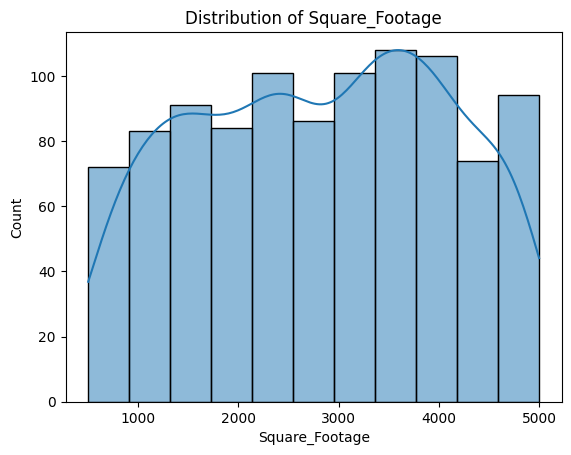

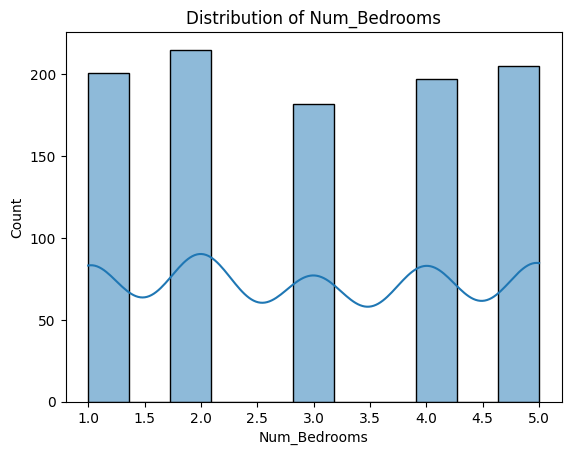

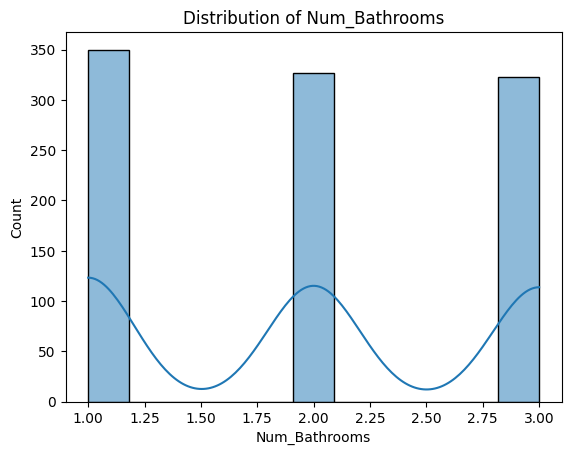

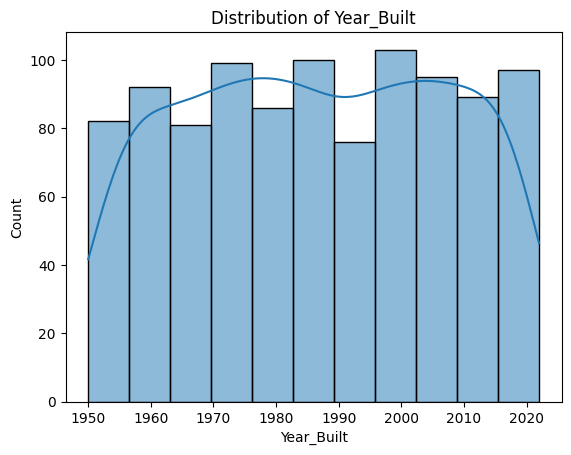

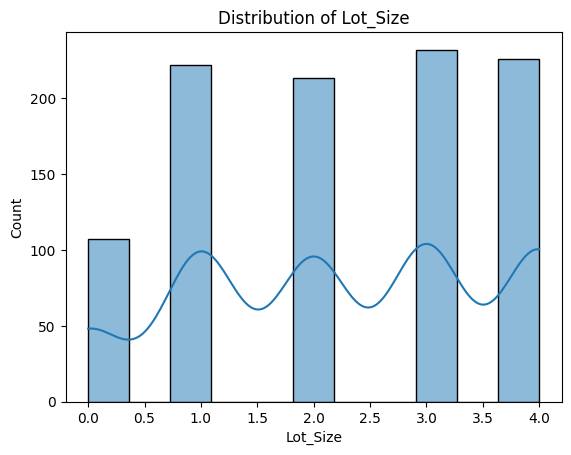

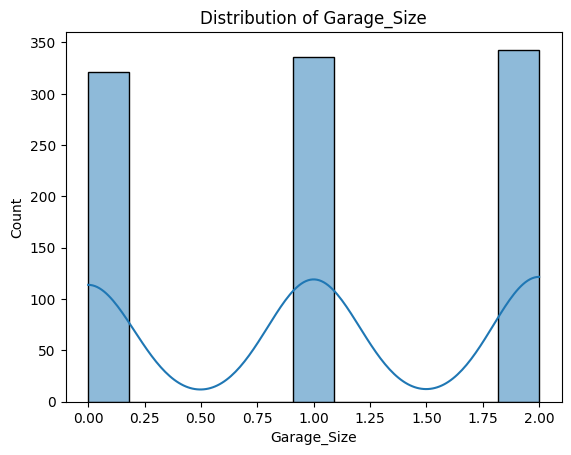

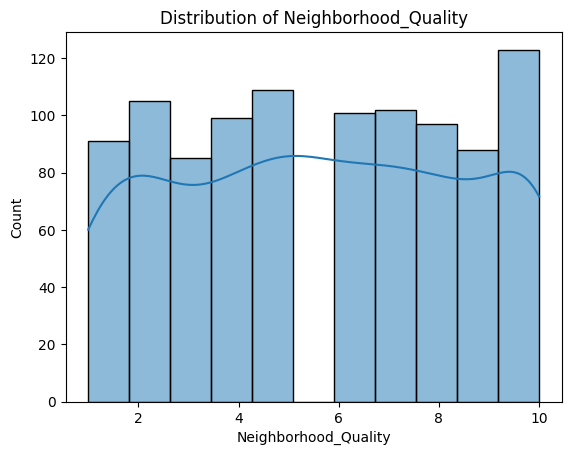

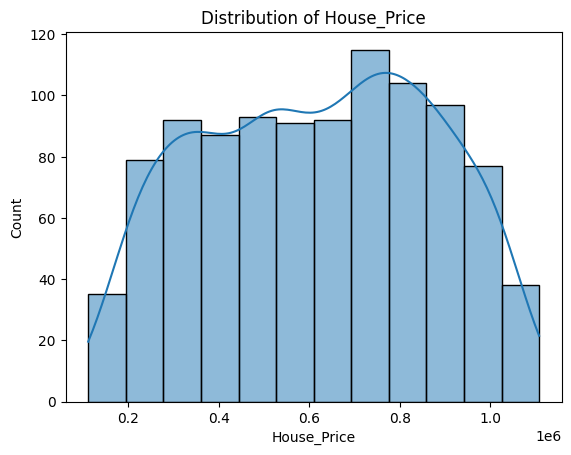

In [28]:
num_cols = ['Square_Footage','Num_Bedrooms','Num_Bathrooms',
            'Year_Built','Lot_Size','Garage_Size',
            'Neighborhood_Quality','House_Price']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Bivariate Analysis

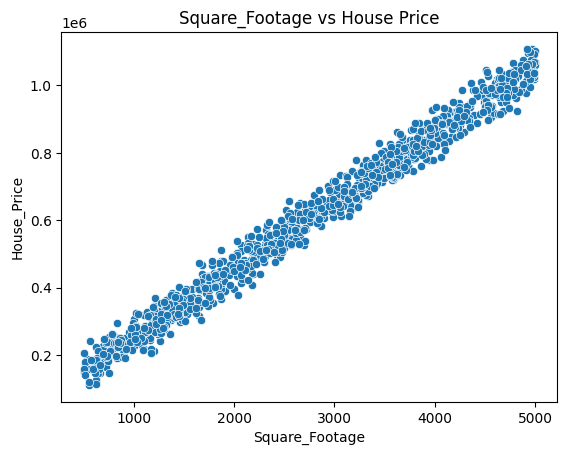

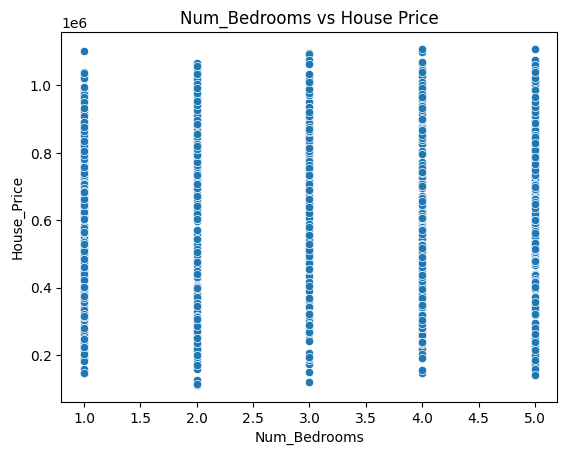

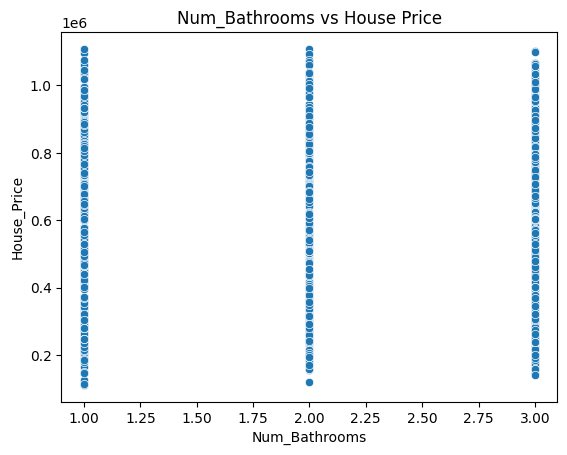

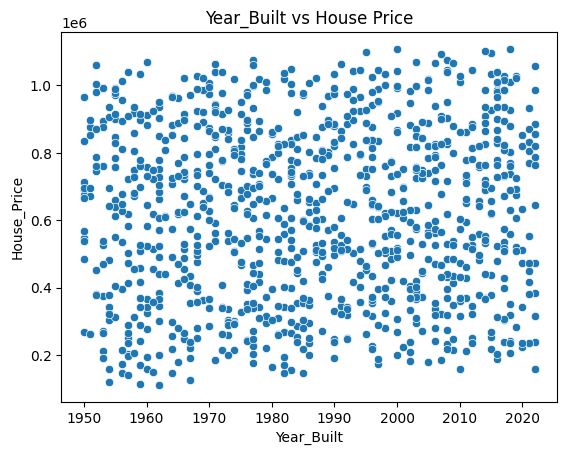

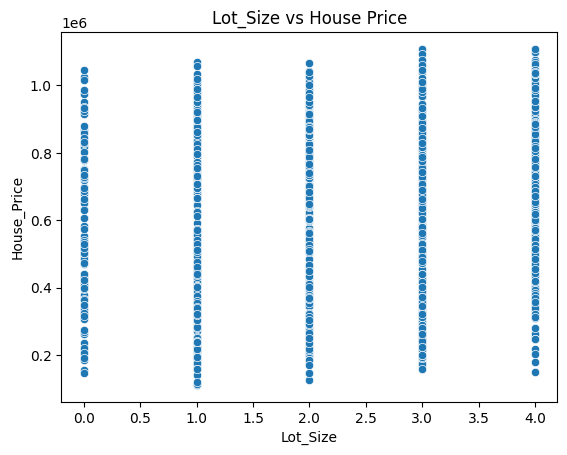

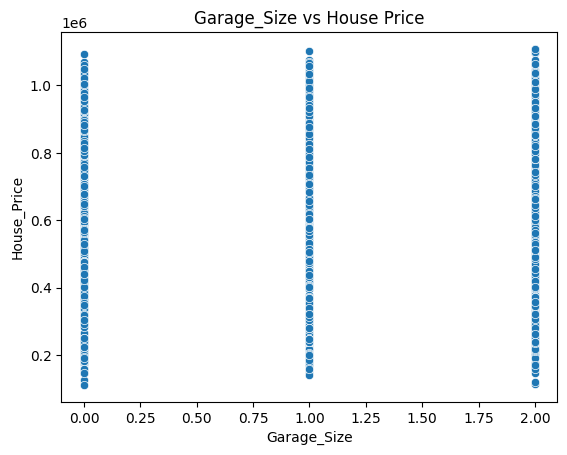

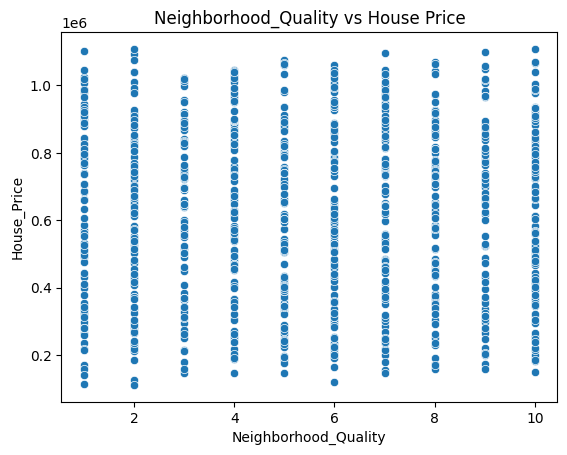

In [29]:
for col in num_cols[:-1]:   # exclude target
    plt.figure()
    sns.scatterplot(x=df[col], y=df['House_Price'])
    plt.title(f"{col} vs House Price")
    plt.show()

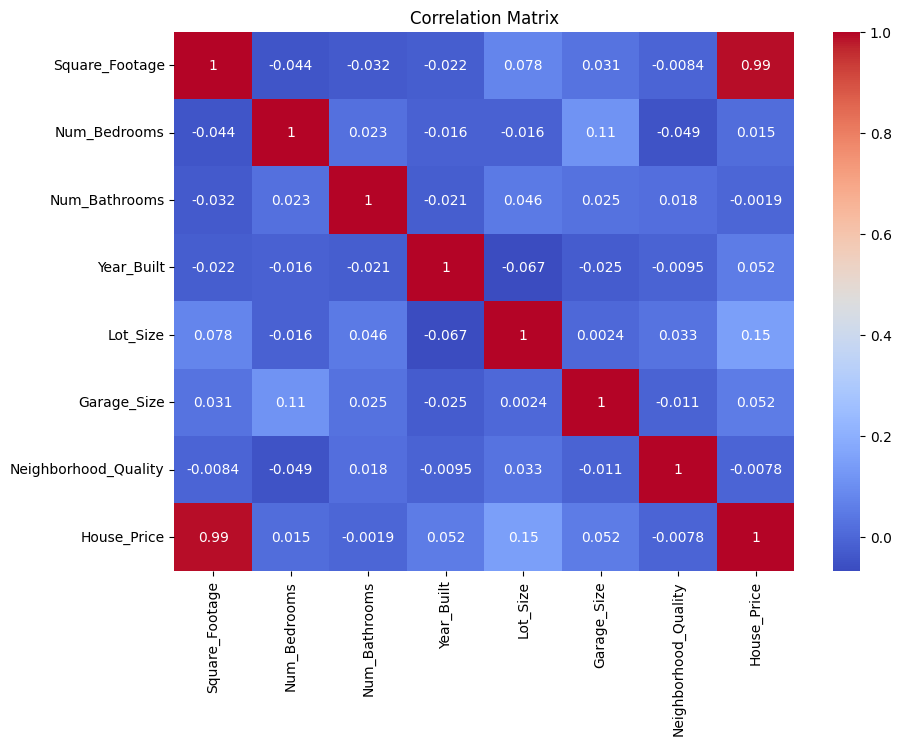

In [30]:
corr = df.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Build a Simple Linear Regression model to predict the Sale price of the house. Use Area as the independent variable.

In [31]:
X = df[['Square_Footage']]   # Area
y = df['House_Price'] 

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [35]:
y_pred = model.predict(X_test)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9832220818502722
MAE: 27179.529737263703
RMSE: 32885.94185570302


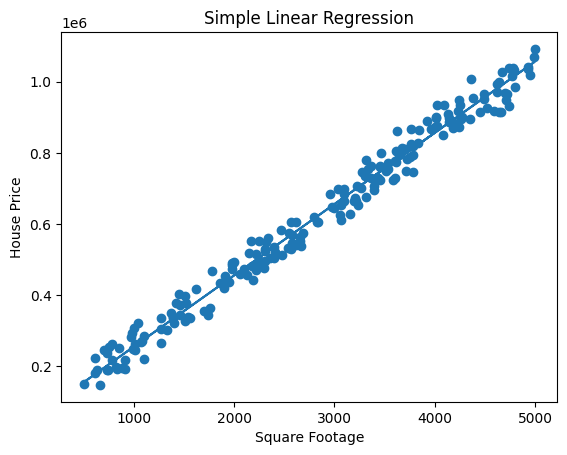

In [37]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Square Footage")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.show()

# Build Multiple Linear Regression model to predict Sale price of the house.

In [38]:
features = ['Square_Footage','Num_Bedrooms','Num_Bathrooms',
            'Year_Built','Lot_Size','Garage_Size','Neighborhood_Quality']

X = df[features]
y = df['House_Price']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [41]:
y_pred = model.predict(X_test)

In [42]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.9981887282775213
MAE: 8831.497537114352
RMSE: 10805.206032972887


In [43]:
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head()

,Actual,Predicted
521,901000,8.760212e+05
737,494537,4.936361e+05
740,949404,9.423974e+05
660,1040389,1.033856e+06
411,794010,7.699912e+05


# Build a model using Lasso and Ridge regression to reduce model complexity.

In [44]:
from sklearn.linear_model import Ridge, Lasso

In [45]:
ridge = Ridge(alpha=1.0)   # alpha = regularization strength
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [46]:
print("Ridge R2:", r2_score(y_test, ridge_pred))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))

Ridge R2: 0.9981883697707888
Ridge RMSE: 10806.275322410791


In [47]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

In [48]:
print("Lasso R2:", r2_score(y_test, lasso_pred))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))

Lasso R2: 0.998188725870893
Lasso RMSE: 10805.213211383843


# Model Selection: Evaluate and compare performance of all the models to find the best mode



In [50]:
#Evaluate All Models Together

# Linear Regression (already trained)
lr_r2 = r2_score(y_test, y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Ridge
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

# Lasso
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

# Create comparison table
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "R2 Score": [lr_r2, ridge_r2, lasso_r2],
    "RMSE": [lr_rmse, ridge_rmse, lasso_rmse]
})
results 

,Model,R2 Score,RMSE
0,Linear Regression,0.998189,10805.206033
1,Ridge,0.998188,10806.275322
2,Lasso,0.998189,10805.213211


In [51]:
#sort best model

results.sort_values(by="R2 Score", ascending=False)

,Model,R2 Score,RMSE
0,Linear Regression,0.998189,10805.206033
2,Lasso,0.998189,10805.213211
1,Ridge,0.998188,10806.275322


In [52]:
#save model

import pickle

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)